## Connecting Libraries 

This section imports all the necessary libraries and modules required for the subsequent tasks. It includes tools for handling medical DICOM images (pydicom), numerical computations (numpy), image processing (cv2), deep learning framework (torch and related modules), pretrained models from torchvision, and evaluation metrics from sklearn. Additionally, the code imports visualization utilities like matplotlib for plotting results such as confusion matrices.

In [1]:
import os
import pydicom
import numpy as np
from sklearn.model_selection import train_test_split
import cv2

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torchvision.models import DenseNet121_Weights
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, roc_auc_score

## Data Loading and Preprocessing
This section handles the loading of medical CT images in DICOM format from the specified folder. It reads each file, filters for CT modality, and assigns labels based on filename keywords indicating contrast presence.

The images are stored as numpy arrays along with their corresponding labels.

After loading, the images are preprocessed — resized to a consistent size and normalized — using the preprocess_images function.

Finally, the entire dataset is split into training and test sets with stratified sampling to preserve class proportions, and all data is converted into PyTorch tensors ready for model training.

In [2]:

folder_path = '/kaggle/input/siim-medical-images/dicom_dir'
#weights_path = '/kaggle/input/densenet121/pytorch/densenet/1/densenet121_gogo.pth'
weights_path = '/kaggle/input/gogo-weights/pytorch/default/1/densenet121_weights_gogo.pth'
slices=[]
y=[]



for filename in os.listdir(folder_path):
    if filename.endswith(".dcm"):
        filepath = os.path.join(folder_path, filename)
        ds = pydicom.dcmread(filepath)

        if hasattr(ds, 'Modality') and ds.Modality == 'CT':


            label = 0  # Значение по умолчанию
            if 'contrast_1' in filename.lower():
                label = 1
                slices.append(ds.pixel_array)
                y.append(label)
            elif 'contrast_0' in filename.lower():
                label = 0
                slices.append(ds.pixel_array)
                y.append(label)

      
all = np.array(slices)
y_all = np.array(y)


### Preparing data for learning


def preprocess_images(images, size=(512,512)):
    images_resized = [cv2.resize(img, size) for img in images]
    images_np = np.array(images_resized, dtype=np.float32)
    images_np /= np.max(images_np)
    if images_np.ndim == 3:
        images_np = images_np[..., np.newaxis]
    return images_np


X_all= preprocess_images(all)
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.3, stratify=y_all)


X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float()
X_test= torch.tensor(X_test).permute(0, 3, 1, 2).float()
y_train = torch.tensor(y_train).long()
y_test= torch.tensor(y_test).long()

## Model Setup and Training Loop

This section covers the loading of the pretrained DenseNet121 model, adapting its input and output layers for our data, moving the model to the training device, and defining the optimizer, loss function, and the training loop.

In [3]:

batch_size = 8
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


model = models.densenet121(weights=None)
model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.classifier = nn.Linear(model.classifier.in_features, 2)  # 2 класса

#Load weights
state_dict = torch.load(weights_path, map_location='cpu')
model.load_state_dict(state_dict)


# Moving the model to the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Now the optimizer, the criterion, and the learning cycle:



criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



num_epochs = 25
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total = 0
    correct = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = total_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

Epoch 1/25, Loss: 0.4481, Accuracy: 0.8000
Epoch 2/25, Loss: 0.4264, Accuracy: 0.8714
Epoch 3/25, Loss: 0.2686, Accuracy: 0.8857
Epoch 4/25, Loss: 0.5089, Accuracy: 0.7714
Epoch 5/25, Loss: 0.6186, Accuracy: 0.8000
Epoch 6/25, Loss: 0.4140, Accuracy: 0.7857
Epoch 7/25, Loss: 0.3306, Accuracy: 0.8571
Epoch 8/25, Loss: 0.2451, Accuracy: 0.9143
Epoch 9/25, Loss: 0.2588, Accuracy: 0.9000
Epoch 10/25, Loss: 0.2417, Accuracy: 0.9143
Epoch 11/25, Loss: 0.3451, Accuracy: 0.9000
Epoch 12/25, Loss: 0.1928, Accuracy: 0.9143
Epoch 13/25, Loss: 0.2647, Accuracy: 0.8714
Epoch 14/25, Loss: 0.2037, Accuracy: 0.9429
Epoch 15/25, Loss: 0.1374, Accuracy: 0.9571
Epoch 16/25, Loss: 0.1122, Accuracy: 0.9429
Epoch 17/25, Loss: 0.1683, Accuracy: 0.9286
Epoch 18/25, Loss: 0.2673, Accuracy: 0.8857
Epoch 19/25, Loss: 0.4799, Accuracy: 0.8714
Epoch 20/25, Loss: 0.2870, Accuracy: 0.8714
Epoch 21/25, Loss: 0.2947, Accuracy: 0.8429
Epoch 22/25, Loss: 0.0971, Accuracy: 0.9714
Epoch 23/25, Loss: 0.2067, Accuracy: 0.90

## Model Evaluation on Training Set

This section evaluates the trained model on the training dataset. The model is set to evaluation mode to disable dropout and batch normalization updates.

AUC-ROC: 1.0000


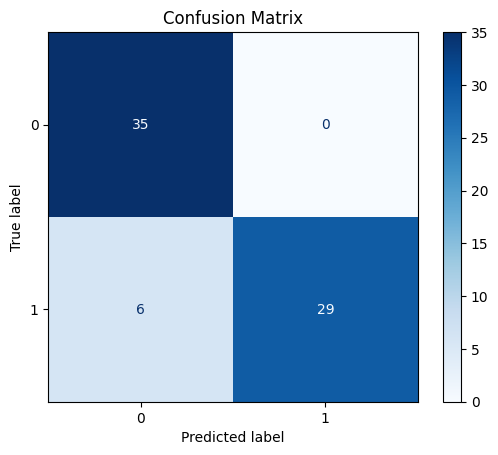

Accuracy: 0.9143
Precision: 1.0000
Recall: 0.8286
F1-score: 0.9062

Classification Report:

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        35
           1       1.00      0.83      0.91        35

    accuracy                           0.91        70
   macro avg       0.93      0.91      0.91        70
weighted avg       0.93      0.91      0.91        70



In [4]:
model.eval()
train_preds = []
train_labels = []
train_preds_probs=[]
train_preds_labels=[]

with torch.no_grad():
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        train_preds.extend(predicted.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
       
        probs = torch.softmax(outputs, dim=1)[:, 1]
        train_preds_probs.extend(probs.cpu().numpy())
        train_preds_labels.extend(labels.cpu().numpy())

# Calculate AUC-ROC
auc_roc = roc_auc_score(train_preds_labels, train_preds_probs)
print(f"AUC-ROC: {auc_roc:.4f}")
        

cm = confusion_matrix(train_labels, train_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

accuracy = accuracy_score(train_labels, train_preds)
precision = precision_score(train_labels, train_preds, average='binary')  # for binary classification
recall = recall_score(train_labels, train_preds, average='binary')
f1 = f1_score(train_labels, train_preds, average='binary')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


print("\nClassification Report:\n")
print(classification_report(train_labels, train_preds))

## Model Evaluation on Test Set

This section evaluates the trained model on the held-out test dataset to measure its generalization performance.

AUC-ROC: 0.9911


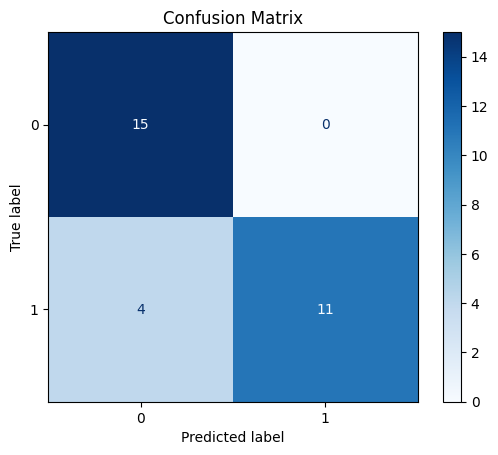

Accuracy: 0.8667
Precision: 1.0000
Recall: 0.7333
F1-score: 0.8462

Classification Report:

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        15
           1       1.00      0.73      0.85        15

    accuracy                           0.87        30
   macro avg       0.89      0.87      0.86        30
weighted avg       0.89      0.87      0.86        30



In [5]:

model.eval()
test_preds = []
test_labels = []
test_preds_probs=[]
test_preds_labels=[]

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        # Получаем вероятности через softmax для класса 1
        probs = torch.softmax(outputs, dim=1)[:, 1]
        test_preds_probs.extend(probs.cpu().numpy())
        test_preds_labels.extend(labels.cpu().numpy())

auc_roc = roc_auc_score(test_preds_labels, test_preds_probs)
print(f"AUC-ROC: {auc_roc:.4f}")



cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds, average='binary') 
recall = recall_score(test_labels, test_preds, average='binary')
f1 = f1_score(test_labels, test_preds, average='binary')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


print("\nClassification Report:\n")
print(classification_report(test_labels, test_preds))

In [7]:
# Save model weights only
MODEL_PATH = "CT Scan Machine Learning Model.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!
